## **David Emilio Vega Bonza, david.vegabonza@colorado.edu**

### **CC 80215162, Bogotá. Colombia**

## CSCA 5632 Unsupervised Algorithms in Machine Learning Final Project


## **Unsupervised Machine Learning for Customer Churn Analysis in Telecom Companies**  

## **1. Project Problem:**
 
Customer churn analysis in telecom companies traditionally relies on supervised learning to predict which customers are likely to leave. However, unsupervised machine learning offers an alternative approach by uncovering hidden patterns and segmenting customers without predefined labels. This project explores how unsupervised learning techniques can help telecom companies identify at-risk customer groups, detect anomalies, and derive actionable insights for retention strategies.  

### **Why Unsupervised Learning for Churn Analysis?**  
1. **No Need for Labeled Data** – Unlike supervised models, unsupervised learning does not require historical churn labels, making it useful when labeled data is scarce or unreliable.  
2. **Discover Hidden Patterns** – Clustering and anomaly detection can reveal unexpected customer behaviors that may lead to churn, beyond what traditional models capture.  
3. **Customer Segmentation** – Grouping customers based on behavior, usage, and demographics helps tailor retention strategies for different segments.  
4. **Early Anomaly Detection** – Unsupervised models can detect unusual activity (e.g., sudden drops in usage) that may indicate potential churn before it happens.  
5. **Complement to Supervised Models** – Unsupervised insights can enhance supervised models by providing new features or refining target definitions.  

### **Key Objectives:**  
- **Apply Clustering Algorithms** (e.g., K-Means, DBSCAN, Hierarchical Clustering) to group customers with similar behavior.  
- **Detect Anomalies** using techniques like Isolation Forest or Autoencoders to flag unusual customer activity.  
- **Analyze Feature Importance** to understand which factors contribute most to customer groupings.  
- **Develop Retention Strategies** based on unsupervised insights, such as personalized offers for high-risk clusters.  

### **Expected Outcomes:**  
- Identification of distinct customer segments with varying churn risks.  
- Detection of early warning signs of churn through anomaly detection.  
- Data-driven recommendations for targeted customer retention campaigns.  

### **Business Impact:**  
By leveraging unsupervised learning, telecom companies can:  

✔ **Proactively retain customers** by identifying at-risk groups before they leave.  
✔ **Optimize marketing spend** by focusing on high-priority segments.  
✔ **Improve customer satisfaction** by addressing pain points discovered through clustering.  
✔ **Enhance predictive models** by integrating unsupervised insights into existing churn prediction systems.  


Unsupervised machine learning provides a powerful alternative (or complement) to traditional churn prediction models. By uncovering hidden patterns and segmenting customers effectively, telecom companies can take proactive steps to reduce churn and improve long-term customer loyalty.  


## **2. Data:**

### **Data Source Description:**

#### Context Data Source:
- **Dataset Name:** Telco Customer Churn (focused customer retention programs)
- **Url:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- **Motivation:** "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

#### Content:
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

**The data set includes information about:**

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

#### Dataset variables detail:

1. **customerID:** Customer ID

2. **gender:** Whether the customer is a male or a female

3. **SeniorCitizen:** Whether the customer is a senior citizen or not (1, 0)

4. **Partner:** Whether the customer has a partner or not (Yes, No)

5. **Dependents:** Whether the customer has dependents or not (Yes, No)

6. **tenure:** Number of months the customer has stayed with the company

7. **PhoneService:** Whether the customer has a phone service or not (Yes, No)

8. **MultipleLines:** Whether the customer has multiple lines or not (Yes, No, No phone service)

9. **InternetService:** Customer’s internet service provider (DSL, Fiber optic, No)

10. **OnlineSecurity:** Whether the customer has online security or not (Yes, No, No internet service)

11. **OnlineBackup:** Whether the customer has online backup or not (Yes, No, No internet service)

12. **DeviceProtection:** Whether the customer has device protection or not (Yes, No, No internet service)

13. **TechSupport:** Whether the customer has tech support or not (Yes, No, No internet service)

14. **StreamingTV:** Whether the customer has streaming TV or not (Yes, No, No internet service)

15. **StreamingMovies:** Whether the customer has streaming movies or not (Yes, No, No internet service)

16. **Contract:** The contract term of the customer (Month-to-month, One year, Two year)

17. **PaperlessBilling:** Whether the customer has paperless billing or not (Yes, No)

18. **PaymentMethod:** The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))

19. **MonthlyCharges:** The amount charged to the customer monthly

20. **TotalCharges:** The total amount charged to the customer

21. **Churn:** Whether the customer churned or not (Yes or No)

### Import the necessary libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
#sns.set_theme()
#sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

import scipy.stats as stats

from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from kmodes.kmodes import KModes
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_squared_error
from kmodes.kprototypes import KPrototypes
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

### Data Overview:

- Reading the dataset
- Understanding the shape of the dataset
- Checking the data types
- Checking for missing values
- Checking for duplicated values
- Identification of categorical and numerical features

In [2]:
df=pd.read_csv("./data/telco-customer-churn.csv")

In [3]:
# Head info
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Head info
print(df.shape)

(7043, 21)


### Check duplicate entries

In [5]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


**Observations:**
- No duplicate rows, no return boolean Series denoting.

In [6]:
# Dataframe Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Setting categorical and numerical variables

In [7]:
# Categorical variables 
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# Numerical variables 
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

### 2. Observations:

- There is no might correlation between the most part of numerical variables.
- We have not found till now how categorical variables might affect the defaulted people.

## **2. (Data) Cleaning:**

About the data wrangling, I started reading the dataset, understanding the shape (as you can see, we initially have a shape of (7043) seven thousand and (43) forty-three records and (21) twenty-one columns, (3) three numerical columns and (16) sixteen categorical columns before the ‘get_dummies’ implementation.  There are no missing or duplicated values.


In [8]:
def data_cleaning():
    # 1. Drop 'customerID' as this column does not gives important information 
    # in the data set
    df.drop('customerID', axis=1, inplace=True)

    # 2. Convert Yes o No to binary (1,0)
    #df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    # 3. Data cleaning for the column 'TotalCharges'
    blank_indexes = df[df['TotalCharges'] == ' '].index.values.tolist()
    #blank_indexes , _ = df[df['TotalCharges'] == ' '].index
    #print(blank_indexes)

    # As we found blank string values for some 'TotalCharges' it will be useful 
    # to assign the value as 'MonthlyCharges' exist
    for index in blank_indexes:
        df.loc[index, 'TotalCharges'] = df.loc[index, 'MonthlyCharges']
        #print(df.iloc[index])

    #Convert TotalCharges to numerical
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

data_cleaning()

### 3. Observations:

I had to develop (3) tasks for data cleaning:

- The first one was to drop the **‘customerID’** column because it does not any value for statistical analysis
- The second one was to convert string values of the column **‘Churn’** from Yes or Not to (1) one or 0 (zero) respectively.
- And finally, I found some blank string data in the column **‘Total Charges’** that was originally an ‘object’ data type, then it was necessary to update all those values, and I did it with the value of the ‘Monthly Charges’ of the customer, in conclusion I also had to update the data type to numeric as a float value.

### Check for missing values

In [9]:
### **Check for missing values**
(df.isnull().sum() / df.shape[0])*100


gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [10]:
# Checking the number of unique values in each column
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6534
Churn                  2
dtype: int64

### Summary Statistics

In [11]:
# Checking summary statistics
df.describe().T

#df_adjt.info()

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.798992,2266.730170,18.80,398.55,1394.55,3786.60,8684.80


## **2. (Data) Exploratory Data Analysis (EDA):**

- Does it include clear explanations on how and why an analysis (EDA) is performed?

1. Does it have proper visualizations?
2. Does it have proper analysis? E.g., histogram, correlation matrix, feature importance (if possible) etc. 
3. Does it have conclusions or discussions? E.g., the EDA summary, findings, discussing foreseen difficulties and/or analysis strategy.

In [12]:
# Function to plot a boxplot and a histogram along the same scale

def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,      # Number of rows of the subplot grid = 2
        sharex = True,  # x-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )                   # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "violet"
    )                   # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )                   # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )                   # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )    

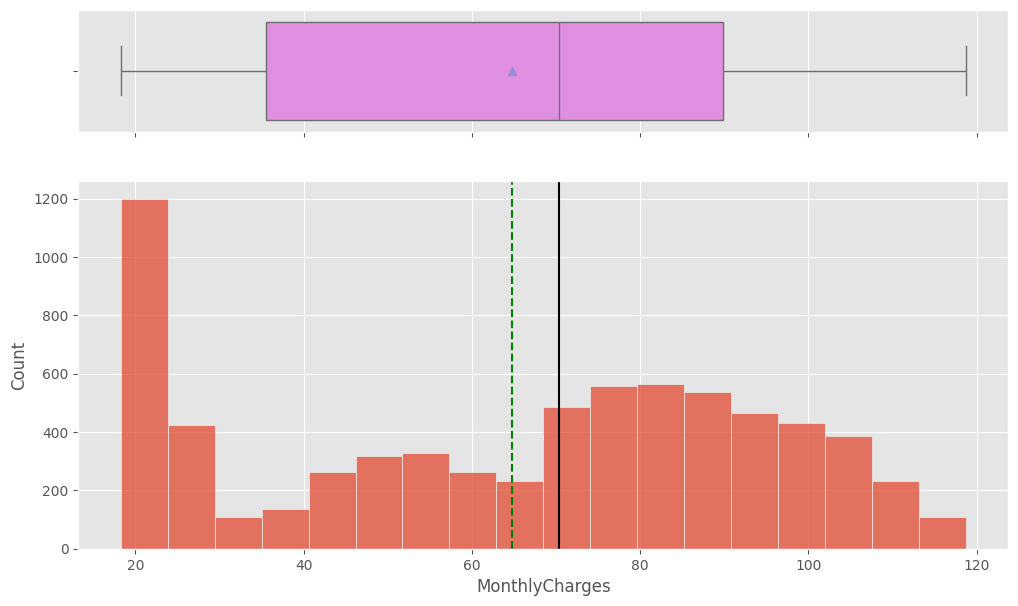

In [13]:
# 1. What is the range of values for the loan amount variable "LOAN"?
histogram_boxplot(df, "MonthlyCharges")

In [14]:
# Checking summary statistics
df['MonthlyCharges'].describe().T

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

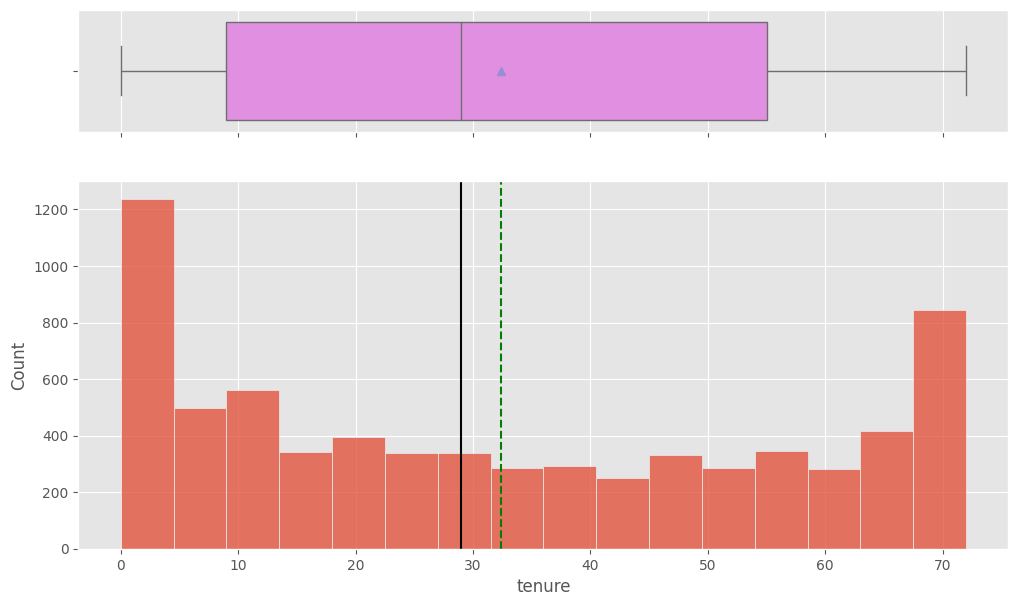

In [15]:
# 2. How does the distribution of years at "tenure" vary across the dataset?
histogram_boxplot(df, "tenure")


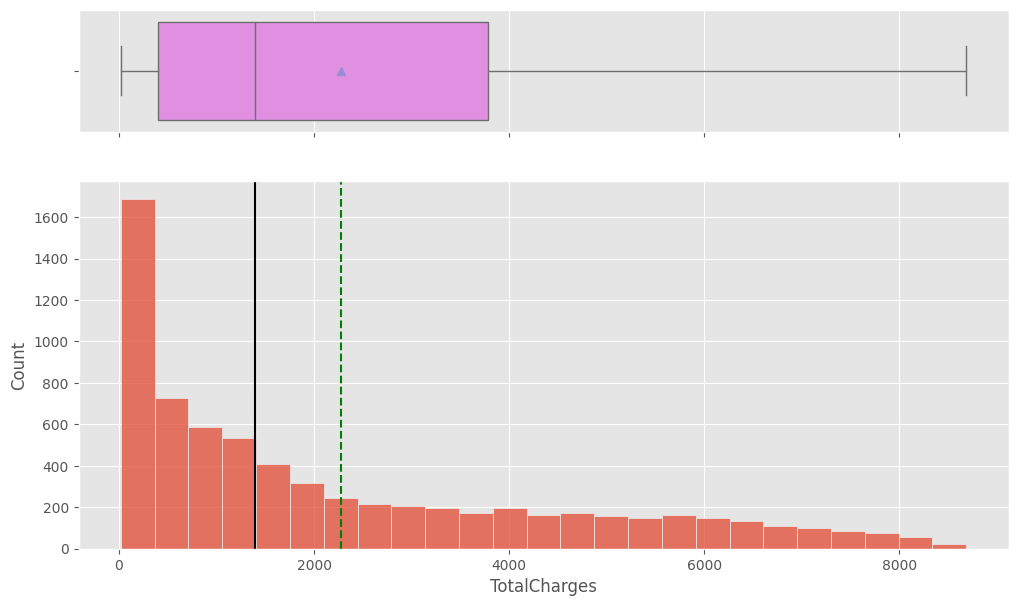

In [16]:
# 3. How does the distribution of years at "TotalCharges" vary across the dataset?
histogram_boxplot(df, "TotalCharges")


In [17]:
# What is the most common category in the Contract variable?

print(df['Contract'].value_counts(normalize = True).mul(100).round(2).astype(str) + '%')

# Maybe draw a plt of this...

Contract
Month-to-month    55.02%
Two year          24.07%
One year          20.91%
Name: proportion, dtype: object


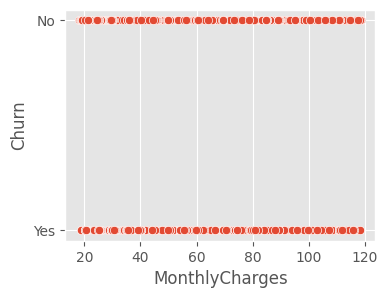

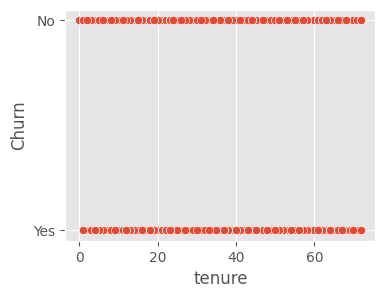

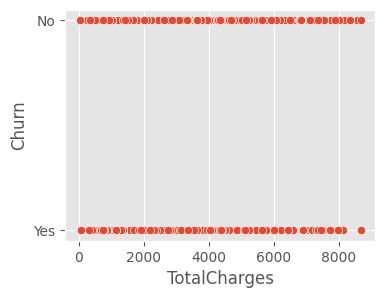

In [18]:
# 6. Do customers who churns have a significantly different MonthlyCharges, tenure, or Total Charges compared to those who are not churned?

df_churned = df[df['Churn'] == 'Yes']
df_not_churned = df[df['Churn'] == 'No']

# Maybe an scater plt comparing churns vs MonthlyCharges amount and no churns vs loan amount
plt.figure(figsize = [4, 3])
sns.scatterplot(x = df.MonthlyCharges, y = df.Churn)
plt.show()

# Maybe an scater plt comparing churns vs tenure amount and no churns vs loan amount
plt.figure(figsize = [4, 3])
sns.scatterplot(x = df.tenure, y = df.Churn)
plt.show()

# Maybe an scater plt comparing churns vs TotalCharges amount and no churns vs loan amount
plt.figure(figsize = [4, 3])
sns.scatterplot(x = df.TotalCharges, y = df.Churn)
plt.show()


**Observation**

- We can see that there is a relation of defaulted people with Loans ranging from 300.000 and 450.000 aproximately.

### **Univariate Analysis**


In [19]:
#Univariate analysis for categorical variables
print('-' * 40)
for i in categorical_cols:
    print(df[i].value_counts(normalize = True))
    print('-' * 40)

----------------------------------------
gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64
----------------------------------------
SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64
----------------------------------------
Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64
----------------------------------------
Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64
----------------------------------------
PhoneService
Yes    0.903166
No     0.096834
Name: proportion, dtype: float64
----------------------------------------
MultipleLines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64
----------------------------------------
InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64
----------------------------------------
OnlineSecurity
No                    

### **Bivariate Analysis**

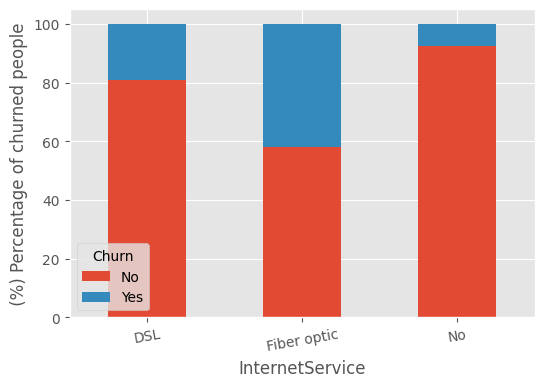

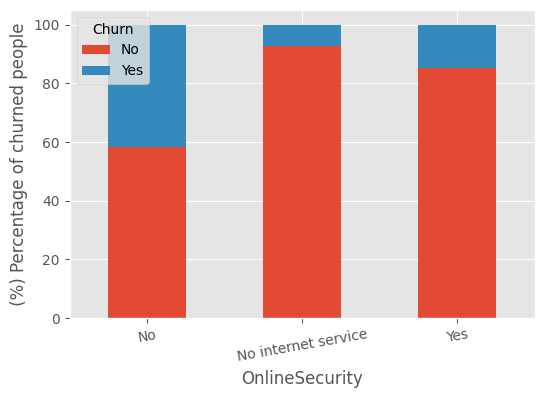

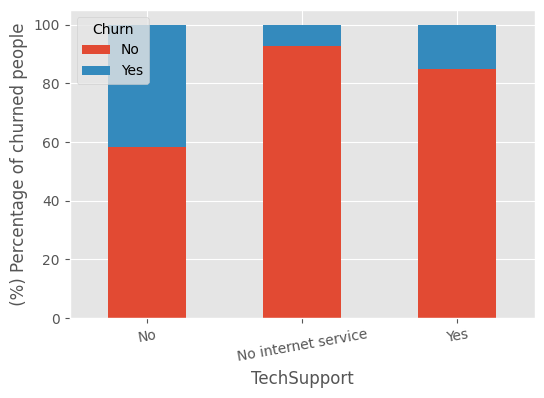

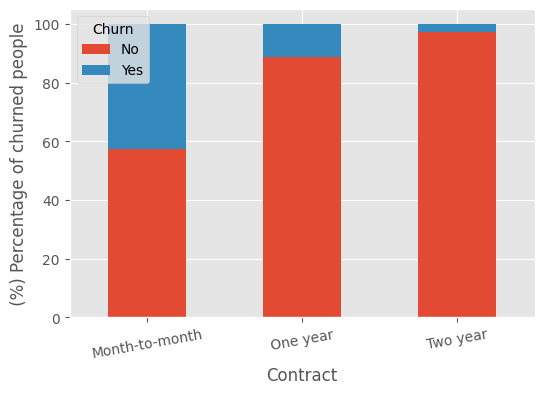

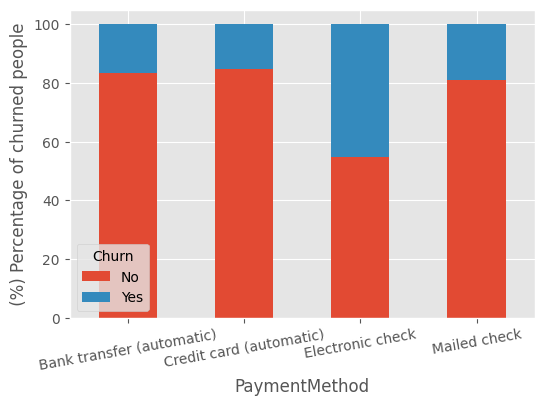

In [20]:
# **We have analyzed different categorical and numerical variables. Let's now check how does attrition rate is related with other categorical variables**

categorical_features = ['InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod']

for i in categorical_features:
    if i != 'Churn':
        (pd.crosstab(df[i], df['Churn'], normalize = 'index')*100).plot(kind = 'bar', figsize = (6, 4), stacked = True, layout= True)
        plt.ylabel(' (%) Percentage of churned people ')
        plt.xticks(rotation = 10)
        

### **Multivariate Analysis**

In [21]:
# DataFrame of numerical colums
numerical_cols_df = df[numerical_cols]

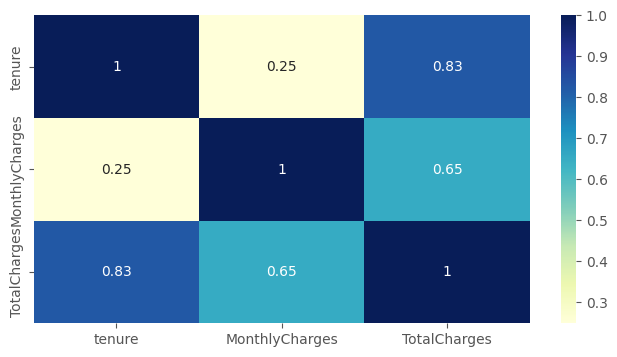

In [22]:
plt.figure(figsize  = (8, 4))
sns.heatmap(numerical_cols_df.corr(), annot = True, cmap = "YlGnBu")
plt.show()

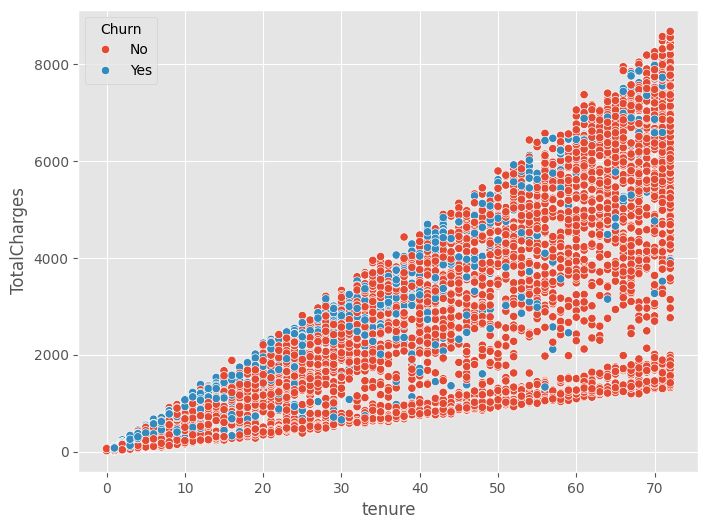

In [23]:
plt.figure(figsize = [8, 6])
sns.scatterplot(x = df.tenure, y = df.TotalCharges, hue= df.Churn, sizes=(50, 25), legend="full",)
plt.show()

**Observation**
- There is probably a high correlation between TotalCharges and tenure variables

### **Let's check the distribution and outliers for each column in the data**

### Treating Outliers

tenure
Skew : 0.24


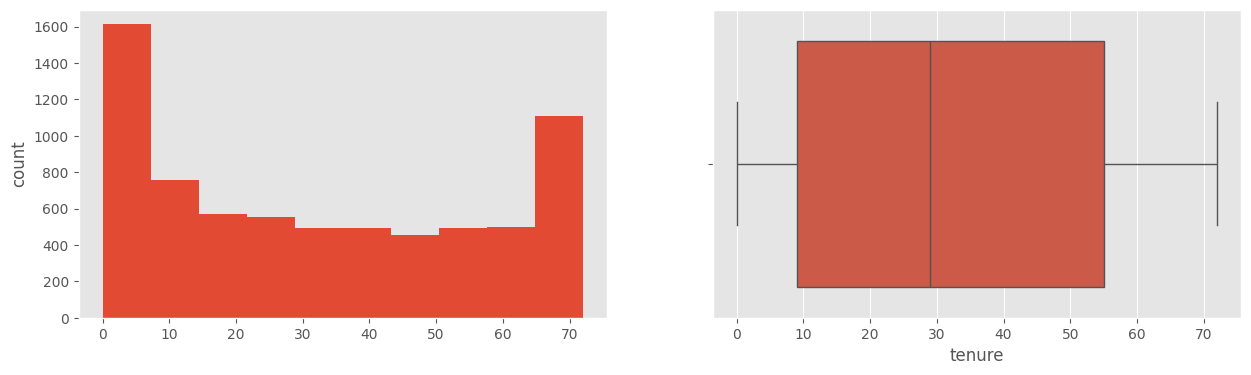

MonthlyCharges
Skew : -0.22


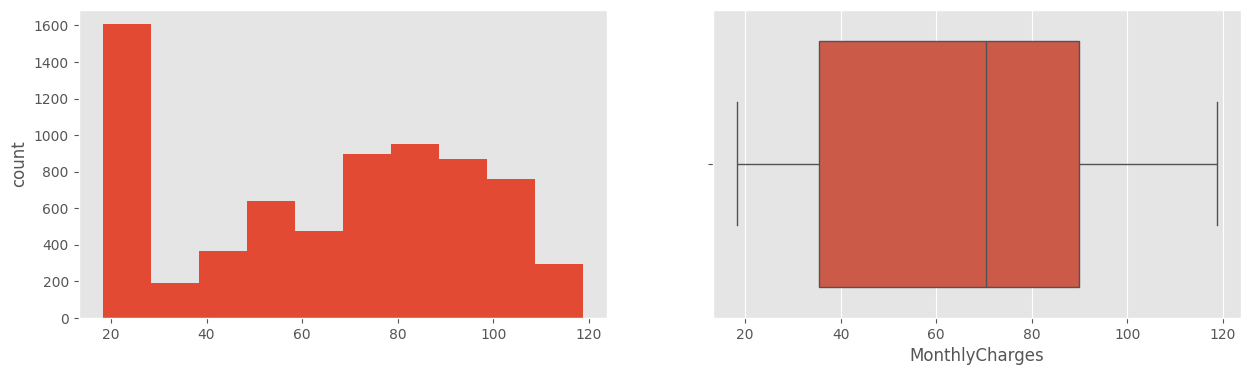

TotalCharges
Skew : 0.96


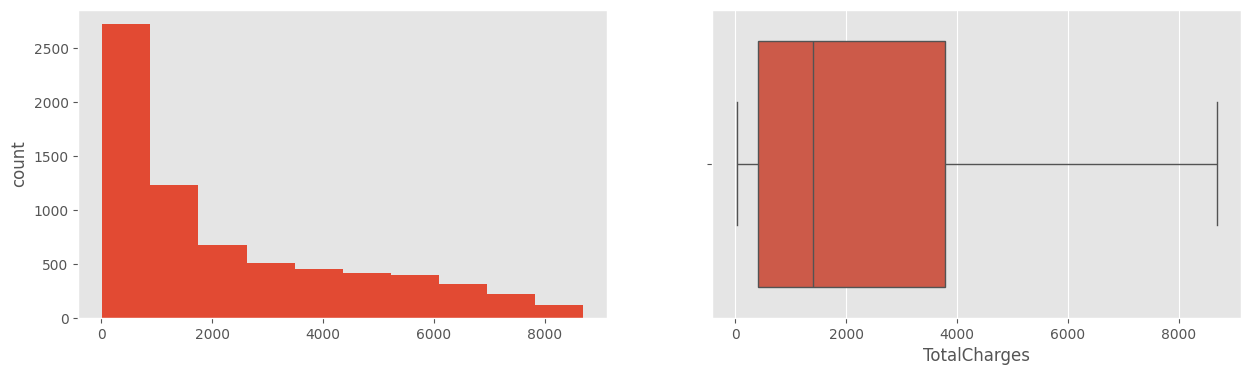

In [24]:
for col in numerical_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    df[col].hist(bins = 10, grid = False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x = df[col])
    plt.show()

### Review of the relationships of categorical data

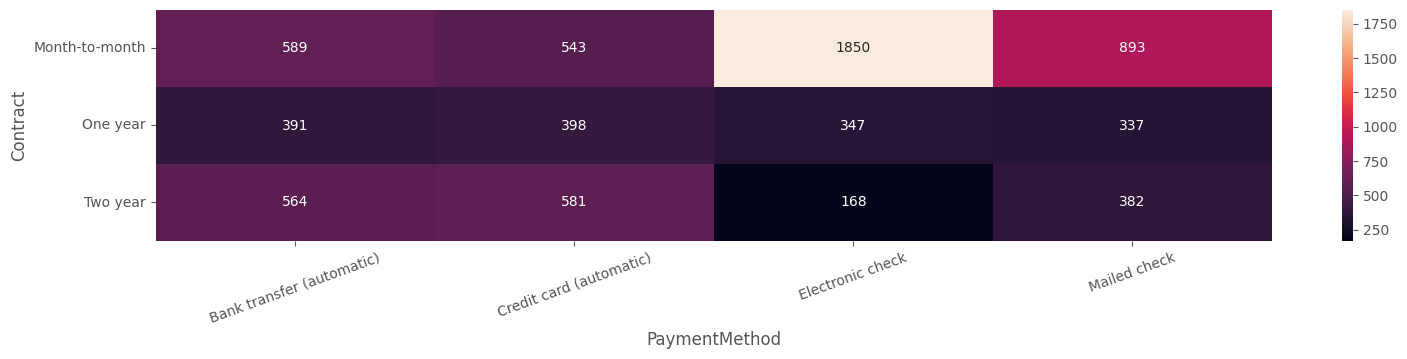

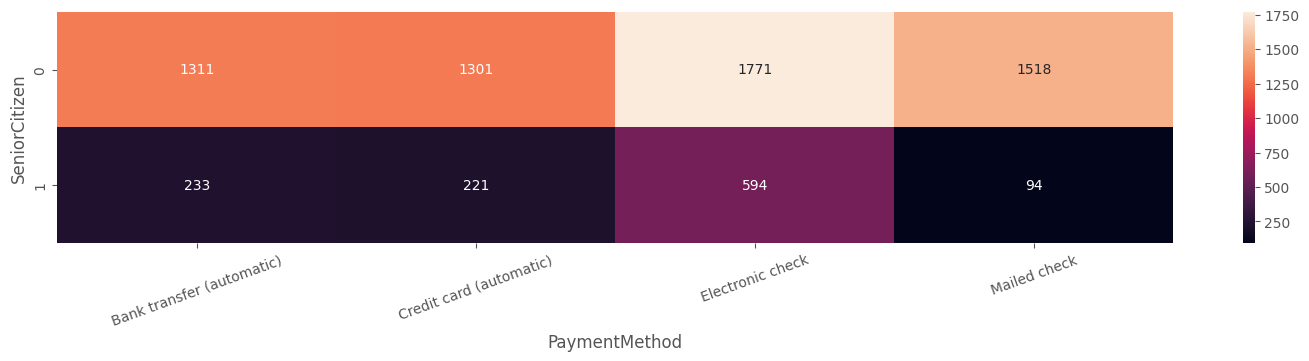

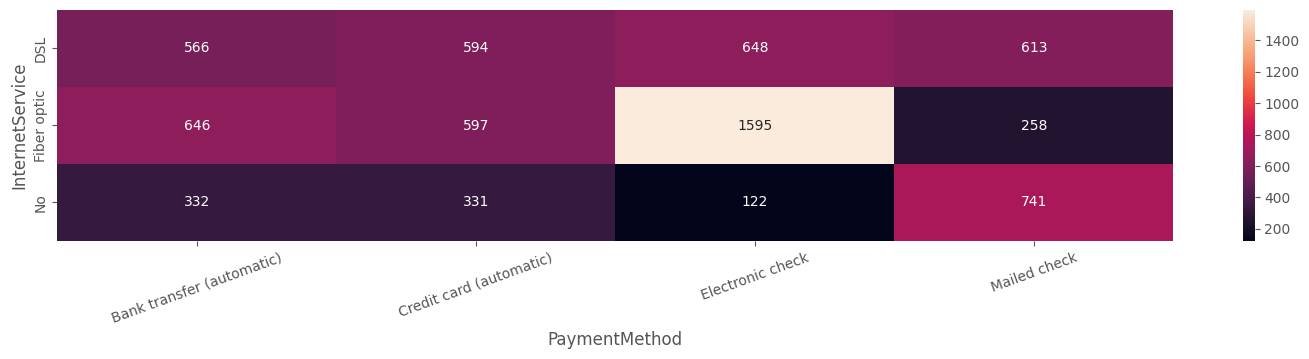

In [25]:
# Review of the relationships of categorical data

fig= plt.figure(figsize = (18, 3))
sns.heatmap(pd.crosstab(index = df['Contract'], columns = df['PaymentMethod']), annot = True, fmt = 'g')
plt.xticks(rotation = 20);

fig= plt.figure(figsize = (18, 3))
sns.heatmap(pd.crosstab(index = df['SeniorCitizen'], columns = df['PaymentMethod']), annot = True, fmt = 'g')
plt.xticks(rotation = 20);

fig= plt.figure(figsize = (18, 3))
sns.heatmap(pd.crosstab(index = df['InternetService'], columns = df['PaymentMethod']), annot = True, fmt = 'g')
plt.xticks(rotation = 20);


### 4. Observations:

- There is no might correlation between the most part of numerical variables.
- We have not found till now how categorical variables might affect the churned customer.

**Important Insights from EDA**

What are the the most important observations and insights from the data based on the EDA performed?


## **3. Unsupervised Models Building - Approach**

Building an unsupervised machine learning model involves several key steps, each designed to prepare, process, and analyze data without labeled outputs. Here’s a structured approach:

### Choose the Right Algorithm  
Select an unsupervised learning algorithm based on your problem type:
- **Clustering** (e.g., K-Means, DBSCAN, Hierarchical Clustering) for grouping similar data points
- **Dimensionality Reduction** (e.g., PCA, t-SNE) for visualizing high-dimensional data
- **Association Rule Learning** (e.g., Apriori, FP-Growth) for finding relationships in transactional data
- **Anomaly Detection** (e.g., Isolation Forest, One-Class SVM) for identifying outliers

### Train the Model  
Apply the chosen algorithm to your dataset. Since there are no predefined labels, the model will try to organize and make sense of the data using patterns or distribution similarities.

### Evaluate and Tune the Model  
Assess model performance using metrics suited for the task:
- **For clustering:** Use metrics like Silhouette Score or Davies-Bouldin Index
- **For dimensionality reduction:** Check variance explained by principal components
- **For anomaly detection:** Compare results with known anomalies (if available)

Fine-tune hyperparameters (e.g., number of clusters in K-Means, distance metric in DBSCAN) to improve results.

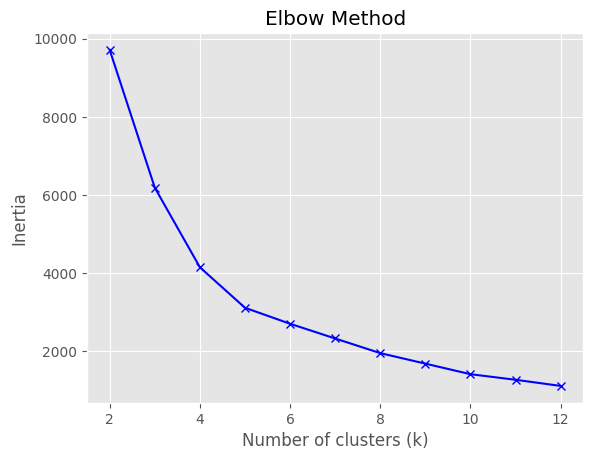

In [26]:
# Select relevant features (numerical)
#features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df[features].fillna(0)  # Handle missing values

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal k using elbow method
inertia = []
k_values = range(2, 13)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.plot(k_values, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


# Plot elbow curve and select optimal k, then fit final model
#kmeans = KMeans(n_clusters=8, random_state=42)
#clusters = kmeans.fit_predict(X_scaled)

Optimal cluster number according with silhouette score: 2


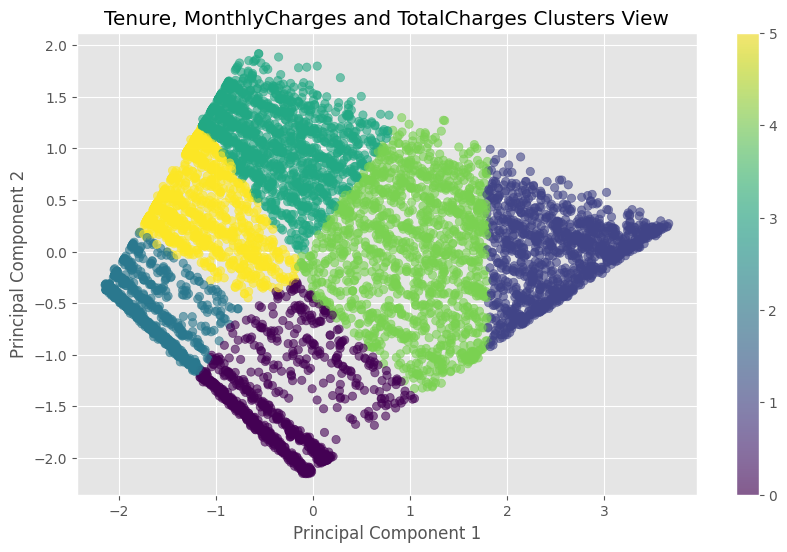


Main words for each cluster:

Cluster 0:
Customer in this cluster: 915


Cluster 1:
Customer in this cluster: 1114


Cluster 2:
Customer in this cluster: 1124


Cluster 3:
Customer in this cluster: 1321


Cluster 4:
Customer in this cluster: 1335


Cluster 5:
Customer in this cluster: 1234


Distribución de TotalCharges reales por cluster:
Cluster    0    1    2    3     4    5
Churn                                 
No       878  960  918  608  1075  735
Yes       37  154  206  713   260  499


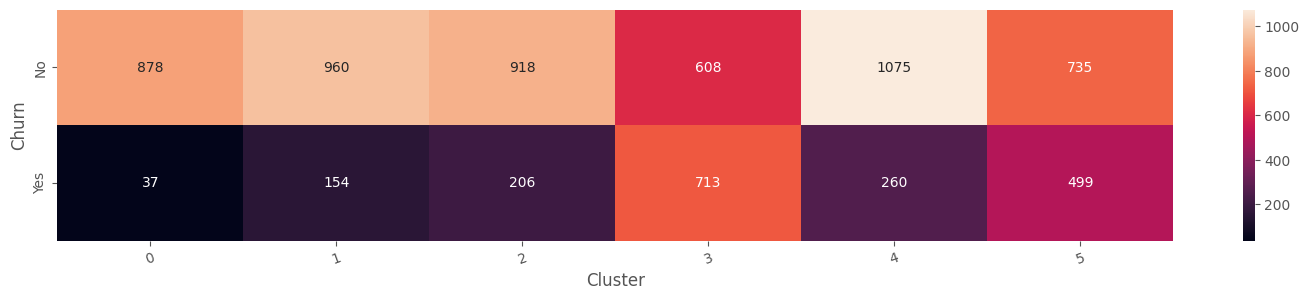

In [27]:
# Silhouette method

silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    #print(labels)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal cluster number according with silhouette score: {optimal_k}")

# 3. Entrenar el modelo K-Means con el k óptimo
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Añadir los clusters al DataFrame
df['Cluster'] = clusters

# 4. Visualización (reducción de dimensionalidad con PCA)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], 
                     c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Tenure, MonthlyCharges and TotalCharges Clusters View')
plt.colorbar(scatter)
plt.show()

# 5. Cluster Analysis
# Features in clusters
print("\nMain words for each cluster:")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
#terms = vectorizer.get_feature_names_out()

for i in range(6):
    print(f"\nCluster {i}:")
    print("Customer in this cluster:", sum(clusters == i))
    print()

if 'Churn' in df.columns:
    print("\nDistribución de TotalCharges reales por cluster:")
    print(pd.crosstab(df['Churn'], df['Cluster']))

    # Review of the relationships of categorical data

fig= plt.figure(figsize = (18, 3))
sns.heatmap(pd.crosstab(index = df['Churn'], columns = df['Cluster']), annot = True, fmt = 'g')
plt.xticks(rotation = 20);

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4945
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2310
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0696
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8681
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7223
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6552
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6280
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6021
Epoch 9/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5959
Epoch 10/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5785
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
mse: 
 7.062295867523399
relative_mse: 
 2.499169411742112


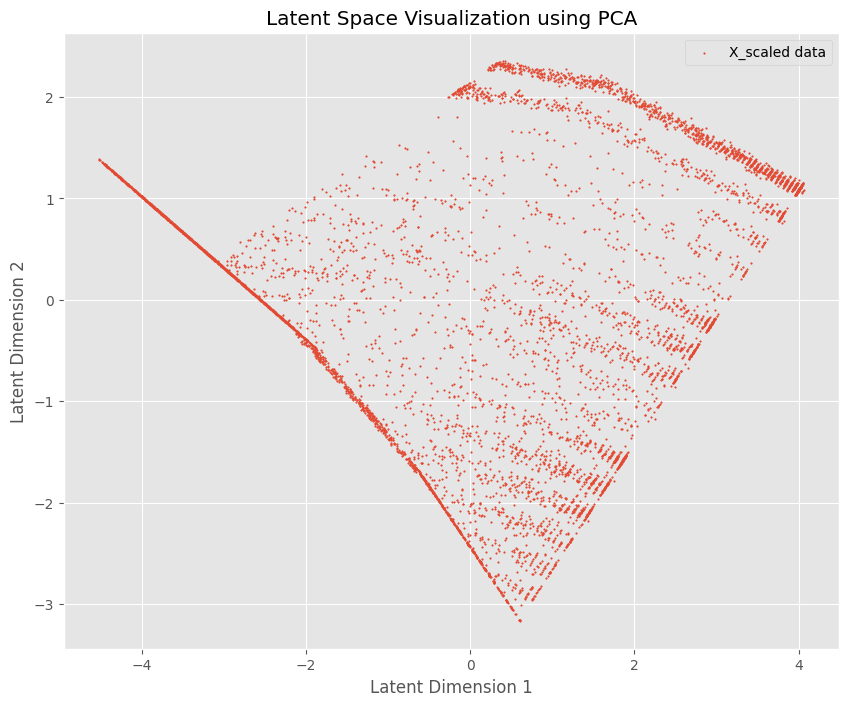

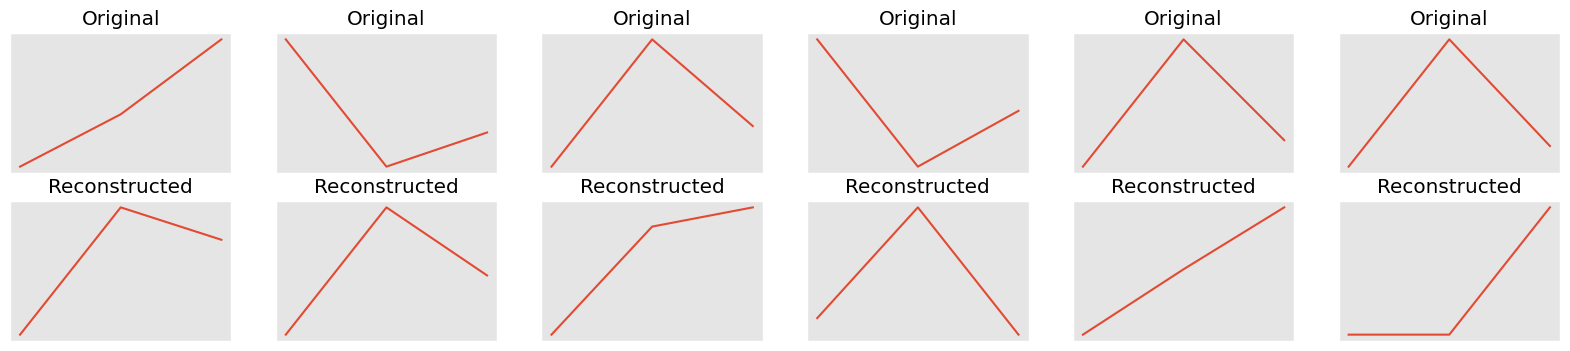

In [28]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Define autoencoder
input_dim = X_scaled.shape[1]
encoding_dim = 3

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation="relu")(input_layer)
decoder = Dense(input_dim, activation="sigmoid")(encoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_scaled, X_scaled, epochs=10, batch_size=32)

# Extract latent space
encoder_model = Model(inputs=input_layer, outputs=encoder)
latent_representation = encoder_model.predict(X_scaled)

# Evaluate the autoencoder
mse = mean_squared_error(X_scaled, latent_representation)
print("mse: \n", mse)

data_range = np.max(X_scaled) - np.min(latent_representation)
relative_mse = mse / data_range
print("relative_mse: \n", relative_mse)

# Dimensionality reduction
pca = PCA(n_components=2)
latent_space_train_pca = pca.fit_transform(latent_representation)
#latent_space_test_pca = pca.transform(latent_space_test)

# Plot the latent space
plt.figure(figsize=(10, 8))
plt.scatter(latent_space_train_pca[:, 0], latent_space_train_pca[:, 1], s=1, label='X_scaled data')
#plt.scatter(latent_space_test_pca[:, 0], latent_space_test_pca[:, 1], s=1, label='Testing data', alpha=0.5)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Visualization using PCA')
plt.legend()
plt.show()


n = 6  # Number of samples to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original data
    ax = plt.subplot(2, n, i + 1)
    plt.plot(X_scaled[i])
    ax.set_title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed data
    ax = plt.subplot(2, n, i + 1 + n)
    plt.plot(latent_representation[i])
    ax.set_title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [29]:
from mlxtend.frequent_patterns import apriori, association_rules

# Create binary matrix of services
services = ['PhoneService', 'MultipleLines', 'InternetService', 
           'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
           'TechSupport', 'StreamingTV', 'StreamingMovies']
service_df = pd.get_dummies(df[services])

# Find frequent itemsets
frequent_itemsets = apriori(service_df, min_support=0.1, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

#rules = association_rules(frq_items, metric ="lift", min_threshold = 1) 
rules = rules.sort_values(['confidence', 'lift'], ascending =[True, False]) 

print(rules)
print(rules.head()) 


                                             antecedents  \
7133                                  (PhoneService_Yes)   
8601                                  (PhoneService_Yes)   
2877                                  (PhoneService_Yes)   
2718                                  (PhoneService_Yes)   
8661                                  (PhoneService_Yes)   
...                                                  ...   
23815  (StreamingTV_No internet service, DeviceProtec...   
24069  (StreamingTV_No internet service, DeviceProtec...   
24323  (StreamingTV_No internet service, DeviceProtec...   
24577  (StreamingTV_No internet service, DeviceProtec...   
25086  (StreamingTV_No internet service, DeviceProtec...   

                                             consequents  antecedent support  \
7133   (OnlineSecurity_No, MultipleLines_No, OnlineBa...            0.903166   
8601   (OnlineSecurity_No, DeviceProtection_No, TechS...            0.903166   
2877   (TechSupport_No, OnlineBackup_Ye

### **K-Modes analysis for categorical data**

1. Fit KModes and Get Cluster Labels
2. Reduce Dimensionality for Visualization.
    Since categorical data isn't directly plottable, you can:
    - Encode the data (using one-hot encoding).
    - Apply dimensionality reduction (PCA, t-SNE).

----------------------------------------
InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64
----------------------------------------
OnlineSecurity
No                     0.496663
Yes                    0.286668
No internet service    0.216669
Name: proportion, dtype: float64
----------------------------------------
TechSupport
No                     0.493114
Yes                    0.290217
No internet service    0.216669
Name: proportion, dtype: float64
----------------------------------------
Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64
----------------------------------------
PaymentMethod
Electronic check             0.335794
Mailed check                 0.228880
Bank transfer (automatic)    0.219225
Credit card (automatic)      0.216101
Name: proportion, dtype: float64
----------------------------------------
<class 'pandas.core.frame.

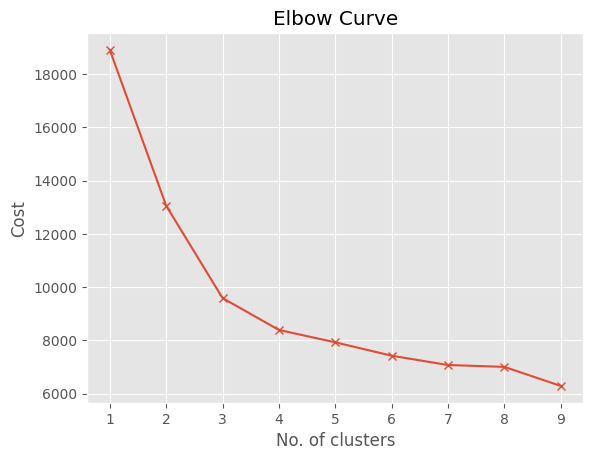

In [30]:
# Creating a list of columns for which we will create dummy variables
categorical_features = ['InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod']

# Setting categorical variables
df=pd.read_csv("./data/telco-customer-churn.csv")
data_cleaning()
df = df[categorical_features]

#Univariate analysis for categorical variables
print('-' * 40)
for i in categorical_features:
    print(df[i].value_counts(normalize = True))
    print('-' * 40)


df.info()

'''
# Encode categorical features
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
'''
''' 2. K-Modes Clustering
K-Modes works well with categorical data because it replaces the Euclidean distance with a simple matching approach.
'''
print(df)

cost = []
K = range(1,10)
for k in list(K):
    kmode = KModes(n_clusters=k, init = "Huang", n_init = 5, verbose=1)
    kmode.fit_predict(df)
    cost.append(kmode.cost_)
    
plt.plot(K, cost, 'x-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Curve')
plt.show()

In [31]:
optimal_clusters_kmodes = 6

kmode = KModes(n_clusters=optimal_clusters_kmodes, init = "Huang", n_init = 5, verbose=1)
clusters_kmodes = kmode.fit_predict(df)
df['Cluster_KModes'] = clusters_kmodes

print("==============================================")
print(categorical_features)
print("Cluster modes:")
print(kmode.cluster_centroids_)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 2262, cost: 8106.0
Run 1, iteration: 2/100, moves: 429, cost: 8106.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 2712, cost: 7374.0
Run 2, iteration: 2/100, moves: 8, cost: 7374.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 1626, cost: 7895.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 8587.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 439, cost: 8868.0
Best run was number 2
['InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod']
Cluster modes:
[['DSL' 'No' 'No' 'Month-to-month' 'Mailed check']
 ['Fiber optic' 'No' 'No' 'Month-to-month' 'Electronic check']
 ['DSL' 'Yes' 'Yes

### **Plotting clusters from Kmodes model**

      InternetService  OnlineSecurity  TechSupport  Contract  PaymentMethod
0                   0               0            0         0              2
1                   0               2            0         1              3
2                   0               2            0         0              3
3                   0               2            2         1              0
4                   1               0            0         0              2
...               ...             ...          ...       ...            ...
7038                0               2            2         1              3
7039                1               0            0         1              1
7040                0               2            0         0              2
7041                1               0            0         0              3
7042                1               2            2         2              0

[7043 rows x 5 columns]


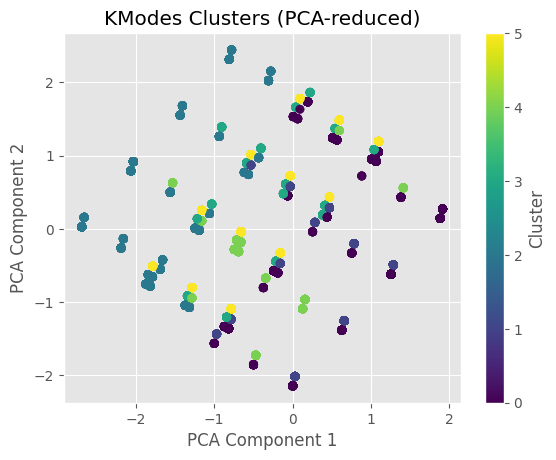

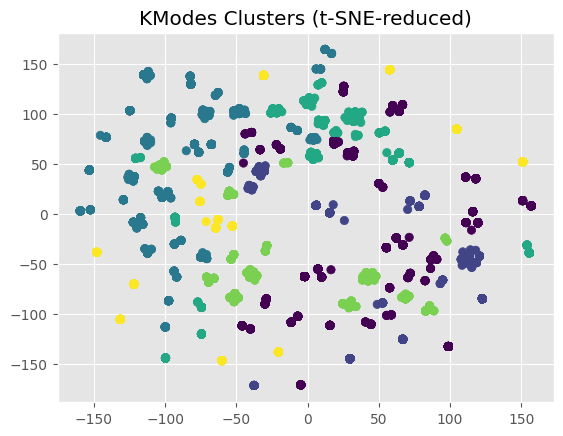

In [32]:
# Encode categorical features
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

df = df[categorical_features]
# Reduce to 2D using PCA

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df)

print(df)

# Plot the clusters - clusters_kmodes
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters_kmodes, cmap='viridis')
plt.title("KModes Clusters (PCA-reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# Reduce to 2D using TSNE
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(df)

plt.scatter(reduced_data_tsne[:, 0], reduced_data_tsne[:, 1], c=clusters_kmodes, cmap='viridis')
plt.title("KModes Clusters (t-SNE-reduced)")
plt.show()


### **Plotting clusters from Hierarchical Clustering model**

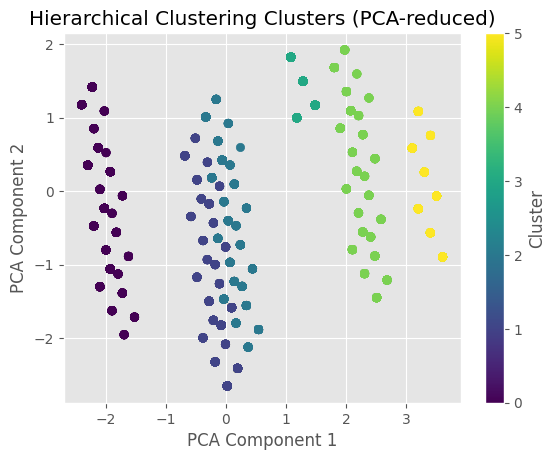

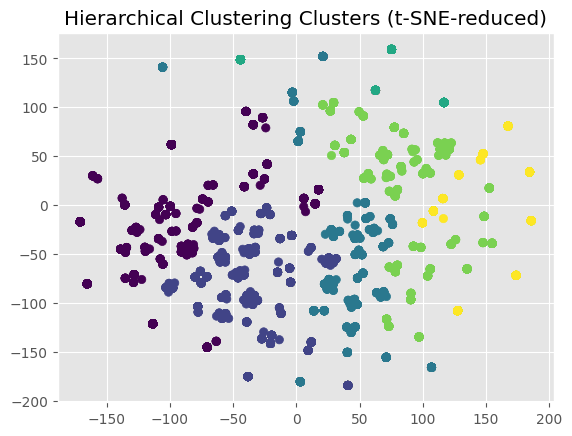

In [33]:
''' 3. Hierarchical Clustering
Using Agglomerative Clustering with Hamming distance.
'''
hierarchical = AgglomerativeClustering(n_clusters=6, linkage='ward')
clusters_hierarchical = hierarchical.fit_predict(df)
df['Cluster_Hierarchical'] = clusters_hierarchical

# Reduce to 2D using PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df)

# Plot the clusters - clusters_kmodes
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters_hierarchical, cmap='viridis')
plt.title("Hierarchical Clustering Clusters (PCA-reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# Reduce to 2D using TSNE
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(df)

plt.scatter(reduced_data_tsne[:, 0], reduced_data_tsne[:, 1], c=clusters_hierarchical, cmap='viridis')
plt.title("Hierarchical Clustering Clusters (t-SNE-reduced)")
plt.show()


In [34]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

### **Silhouette Score**
#- Measures how similar a point is to its own cluster compared to other clusters.
#- Ranges from **-1 (worst)** to **+1 (best)**.
#- A high value indicates good separation.

#### **Calinski-Harabasz Index (Variance Ratio Criterion)**
##- Measures the ratio of between-cluster dispersion to within-cluster dispersion.
##- Higher values indicate better-defined clusters.

#### **Davies-Bouldin Index**
#- Measures the average similarity between each cluster and its most similar one.
#- **Lower values** indicate better clustering.

clusters_analyzed = [clusters_hierarchical, clusters_kmodes ]

print('---------------------------')
silhouette_avg = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {round(silhouette_avg,2)}")
ch_score = calinski_harabasz_score(X_scaled, clusters)
print(f"Calinski-Harabasz Score: {round(ch_score,2)}")
db_score = davies_bouldin_score(X_scaled, clusters)
print(f"Davies-Bouldin Index: {round(db_score,2)}")
print('---------------------------')

for type_cluster in clusters_analyzed:
    print('---------------------------')
    silhouette_avg = silhouette_score(df, type_cluster)
    print(f"Silhouette Score: {round(silhouette_avg,2)}")
    ch_score = calinski_harabasz_score(df, type_cluster)
    print(f"Calinski-Harabasz Score: {round(ch_score,2)}")
    db_score = davies_bouldin_score(df, type_cluster)
    print(f"Davies-Bouldin Index: {round(db_score,2)}")
print('---------------------------')

---------------------------
Silhouette Score: 0.4
Calinski-Harabasz Score: 9595.31
Davies-Bouldin Index: 0.87
---------------------------
---------------------------
Silhouette Score: 0.51
Calinski-Harabasz Score: 5275.08
Davies-Bouldin Index: 0.94
---------------------------
Silhouette Score: 0.19
Calinski-Harabasz Score: 1575.39
Davies-Bouldin Index: 2.19
---------------------------


In [35]:
data ={
    'Cluster': ['0', '1', '2', '3', '4', '5'],
    'InternetService': ['Fiber optic', 'DSL', 'DSL', 'DSL', 'Fiber optic', 'No'],
    'OnlineSecurity' : ['No', 'No', 'Yes', 'Yes', 'No', 'No internet service' ],
    'TechSupport' : ['No', 'No', 'No', 'Yes', 'No', 'No internet service' ],
    'Contract' : ['Month-to-month', 'Month-to-month', 'One year', 'Two year', 'Month-to-month', 'Two year'],
    'PaymentMethod': ['Bank transfer (automatic)', 'Electronic check', 'Credit card (automatic)', 'Bank transfer (automatic)', 'Electronic check', 'Mailed check']}

result_df = pd.DataFrame(data)
result_df.head(6)

,Cluster,InternetService,OnlineSecurity,TechSupport,Contract,PaymentMethod
0,0,Fiber optic,No,No,Month-to-month,Bank transfer (automatic)
1,1,DSL,No,No,Month-to-month,Electronic check
2,2,DSL,Yes,No,One year,Credit card (automatic)
3,3,DSL,Yes,Yes,Two year,Bank transfer (automatic)
4,4,Fiber optic,No,No,Month-to-month,Electronic check
5,5,No,No internet service,No internet service,Two year,Mailed check


In [36]:
categorical_features_all = ['InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod', 'Churn']

# Setting categorical variables
df=pd.read_csv("./data/telco-customer-churn.csv")
data_cleaning()
df = df[categorical_features_all]

cluster_0 = df[(df['InternetService'] == 'Fiber optic') & (df['OnlineSecurity'] == 'No') & (df['TechSupport'] == 'No') & (df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Bank transfer (automatic)') ]
cluster_1 = df[(df['InternetService'] == 'DSL') & (df['OnlineSecurity'] == 'No') & (df['TechSupport'] == 'No') & (df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check') ]
cluster_2 = df[(df['InternetService'] == 'DSL') & (df['OnlineSecurity'] == 'Yes') & (df['TechSupport'] == 'No') & (df['Contract'] == 'One year') & (df['PaymentMethod'] == 'Credit card (automatic)') ]
cluster_3 = df[(df['InternetService'] == 'DSL') & (df['OnlineSecurity'] == 'Yes') & (df['TechSupport'] == 'Yes') & (df['Contract'] == 'Two year') & (df['PaymentMethod'] == 'Bank transfer (automatic)') ]
cluster_4 = df[(df['InternetService'] == 'Fiber optic') & (df['OnlineSecurity'] == 'No') & (df['TechSupport'] == 'No') & (df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check') ]
cluster_5 = df[(df['InternetService'] == 'No') & (df['OnlineSecurity'] == 'No internet service') & (df['TechSupport'] == 'No internet service') & (df['Contract'] == 'Two year') & (df['PaymentMethod'] == 'Mailed check') ]

print('cluster 0 :', round(cluster_0['Churn'].value_counts(normalize = True)*100,2))
print('-'*50)
print('cluster 1 :', round(cluster_1['Churn'].value_counts(normalize = True)*100,2))
print('-'*50)
print('cluster 2 :', round(cluster_2['Churn'].value_counts(normalize = True)*100,2))
print('-'*50)
print('cluster 3 :', round(cluster_3['Churn'].value_counts(normalize = True)*100,2))
print('-'*50)
print('cluster 4 :', round(cluster_4['Churn'].value_counts(normalize = True)*100,2))
print('-'*50)
print('cluster 5 :', round(cluster_5['Churn'].value_counts(normalize = True)*100,2))
print('-'*50)


cluster 0 : Churn
Yes    51.89
No     48.11
Name: proportion, dtype: float64
--------------------------------------------------
cluster 1 : Churn
No     51.42
Yes    48.58
Name: proportion, dtype: float64
--------------------------------------------------
cluster 2 : Churn
No     91.89
Yes     8.11
Name: proportion, dtype: float64
--------------------------------------------------
cluster 3 : Churn
No     98.53
Yes     1.47
Name: proportion, dtype: float64
--------------------------------------------------
cluster 4 : Churn
Yes    65.82
No     34.18
Name: proportion, dtype: float64
--------------------------------------------------
cluster 5 : Churn
No     99.21
Yes     0.79
Name: proportion, dtype: float64
--------------------------------------------------


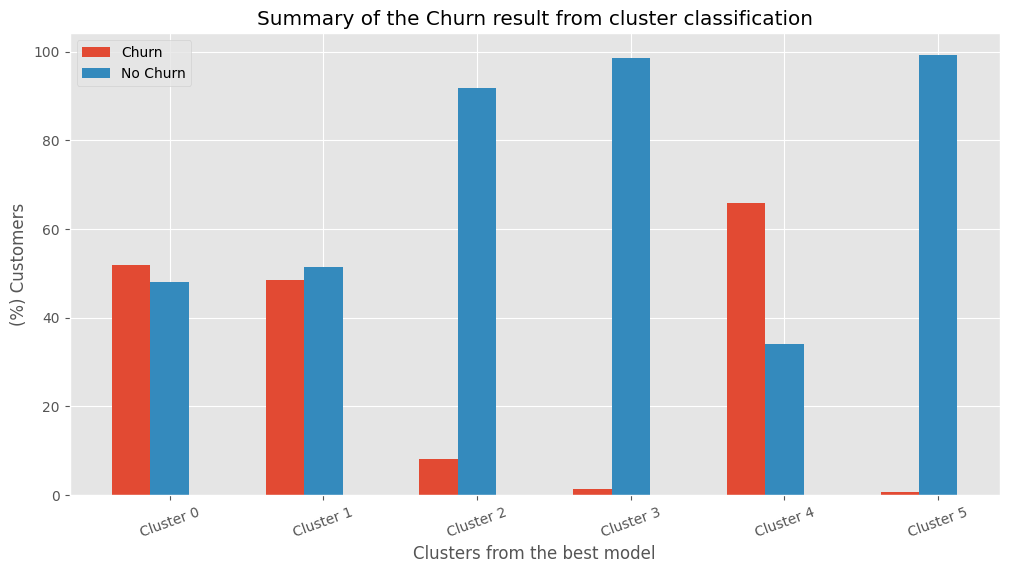

In [37]:
X = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5'] 
Churn = [51.89, 48.58, 8.11, 1.47, 65.82, 0.79 ] 
No_Churn  = [48.11, 51.42, 91.89, 98.53, 34.18, 99.21] 
X_axis = np.arange(len(X)) 
fig = plt.figure(figsize = (12, 6))  
plt.bar(X_axis - 0.25, Churn, 0.25, label = 'Churn') 
plt.bar(X_axis + 0.0, No_Churn, 0.25, label = 'No Churn') 
plt.xticks(X_axis, X) 
plt.xticks(rotation = 20)
plt.title('Summary of the Churn result from cluster classification')
plt.xlabel('Clusters from the best model')
plt.ylabel('(%) Customers')
plt.legend(loc=2) 
plt.show() 

## **4. Discussion and Conclusion:**

Evaluating an unsupervised clustering model like KMeans can be challenging since there are no ground truth labels to compare against. However, there are several metrics and techniques we can use to assess the quality of the clusters:

### 1. **Intra-Cluster Metrics (Compactness)**
These measure how tightly grouped the points within each cluster are.

#### **Inertia (Within-Cluster Sum of Squares)**
- Measures the sum of squared distances of samples to their closest cluster center.
- Lower values indicate tighter clusters.
- Can be accessed via `kmeans.inertia_`.

#### **Silhouette Score**
- Measures how similar a point is to its own cluster compared to other clusters.
- Ranges from **-1 (worst)** to **+1 (best)**.
- A high value indicates good separation.

#### **Calinski-Harabasz Index (Variance Ratio Criterion)**
- Measures the ratio of between-cluster dispersion to within-cluster dispersion.
- Higher values indicate better-defined clusters.


#### **Davies-Bouldin Index**
- Measures the average similarity between each cluster and its most similar one.
- **Lower values** indicate better clustering.


### 2. **Visual Inspection**
Since clustering is often exploratory, visualization can help assess quality:

#### **PCA/T-SNE for Dimensionality Reduction + Plotting**


### **When to Use Which Metric?**
| Metric               | Best When...                          | Limitations                     |
|----------------------|---------------------------------------|----------------------------------|
| **Inertia**          | Comparing different K values (Elbow)  | Decreases with more clusters    |
| **Silhouette Score** | Balanced & dense clusters             | Computationally expensive       |
| **Calinski-Harabasz**| Well-separated clusters               | Biased toward larger K          |
| **Davies-Bouldin**   | Preferring simpler interpretations    | Sensitive to cluster density    |


---

### **Final Note Conclusion**

- Finally, after compare the results obtained from model training, we have this comparison table with metrics for cluster evaluation, such as the Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Index. From the above, we found that the **K-means model** performed the best, with a Silhouette score of 0.51 (zero point five one), indicating a good distance between clusters.

- This allowed us to verify the actual result for each cluster in terms of predicting customer churning:
  - Clusters 2, 3, and 5 grouped the fewest churned customers, which leads us to conclude that this group of **customers with long-term contracts** of more than one year tends to maintain the services contracted with the company.
  - Unlike the previous behavior, we see that clusters 0, 1, and 4 have the **highest number of churned customers**, represented by monthly contracts and without additional services such as Online Security or Tech Support.


Since unsupervised learning lacks ground truth, **combine multiple metrics with domain knowledge** to judge clustering quality effectively. Visualization (PCA/t-SNE) is often the most intuitive way to validate results.


## **Thanks a lot!**